In [13]:
import seaborn as sns
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn

df = load_digits()
batch_size = 64

torch.random.manual_seed(32)

In [14]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset

# --- Train Transform with Augmentation ---
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       
    transforms.RandomHorizontalFlip(),          
    transforms.RandomRotation(15),              
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# --- Validation/Test Transform (no augmentation) ---
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# --- Full CIFAR-10 dataset ---
full_train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)

# --- Train/Val Split ---
train_size = int(0.83 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_indices, val_indices = torch.utils.data.random_split(range(len(full_train_dataset)), [train_size, val_size])

# --- Apply transforms separately for train and val ---\\\\\\\\\\\\\\\
train_dataset = Subset(datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform),
                       train_indices.indices)
val_dataset = Subset(datasets.CIFAR10(root="./data", train=True, download=True, transform=test_transform),
                     val_indices.indices)

# --- Test Dataset ---
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

# --- Dataloaders ---
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")
print(f"Test size  : {len(test_dataset)}")


Train size : 41500
Val size   : 8500
Test size  : 10000


Label: 2 Shape: torch.Size([3, 32, 32])


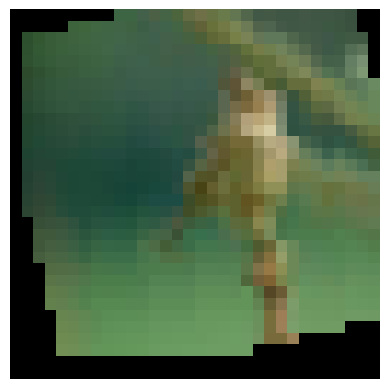

In [15]:
mean = torch.tensor([0.4914, 0.4822, 0.4465])
std = torch.tensor([0.2023, 0.1994, 0.2010])


image, label = train_dataset[6]
print("Label:", label, "Shape:", image.shape)


image = image * std[:, None, None] + mean[:, None, None]

img = image.permute(1, 2, 0).numpy()

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()


In [16]:
class CNNModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  

            nn.Conv2d(32, 254, kernel_size=3, padding=1),
            nn.BatchNorm2d(254),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(254, 254, kernel_size=3, padding=1),
            nn.BatchNorm2d(254),
            nn.ReLU(),
            # nn.MaxPool2d(2),

            nn.Conv2d(254, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)   # logits for 10 classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [17]:
print((64*8*8)*(2/3))

2730.6666666666665


In [18]:
train_loss = []
val_loss = []
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)
criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters(), lr=0.001)

# --- Early Stopping Setup ---
best_val_loss = float("inf")
patience = 5         # stop after 5 epochs with no improvement
counter = 0
best_model_state = None

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    epoch_train_loss = 0.0
    for image, labels in train_loader:
        image, labels = image.to(device), labels.to(device)

        optim.zero_grad()
        logits = model(image)
        loss = criterion(logits, labels)

        loss.backward()
        optim.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_loss.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for image, labels in val_loader:
            image, labels = image.to(device), labels.to(device)
            logits = model(image)
            loss = criterion(logits, labels)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_loss.append(avg_val_loss)

    # ---- Early Stopping Check ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        counter = 0  # reset patience counter
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # ---- Logging ----
    if epoch % 5 == 0:
        print(f"Epoch: {epoch}, "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}")

# ---- Load Best Model ----
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model with Val Loss:", best_val_loss)


Epoch: 0, Train Loss: 1.7438, Val Loss: 1.4749
Epoch: 5, Train Loss: 1.0736, Val Loss: 1.2126
Epoch: 10, Train Loss: 0.8596, Val Loss: 0.8315
Epoch: 15, Train Loss: 0.7342, Val Loss: 0.6493
Epoch: 20, Train Loss: 0.6324, Val Loss: 0.6008
Epoch: 25, Train Loss: 0.5596, Val Loss: 0.5459
Epoch: 30, Train Loss: 0.5007, Val Loss: 0.5714
Epoch: 35, Train Loss: 0.4545, Val Loss: 0.4901
Epoch: 40, Train Loss: 0.4126, Val Loss: 0.4598
Early stopping at epoch 45
Loaded best model with Val Loss: 0.45983695546935377


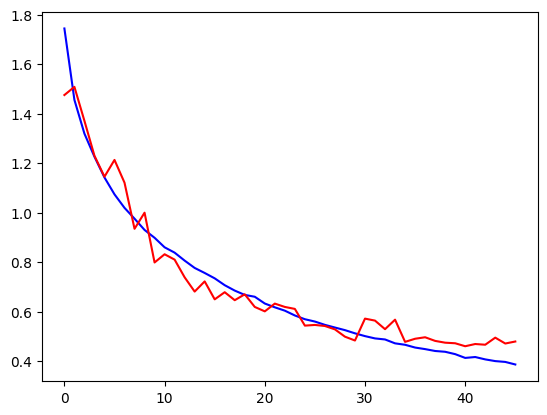

In [20]:

plt.plot([i for i in range(46)],train_loss,c='b')
plt.plot([i for i in range(46)],val_loss,c='r')

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # make sure model is on correct device
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)  # <-- move batch to device
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())   # move back to CPU for sklearn
        all_labels.extend(yb.cpu().numpy())

# --- Metrics ---
cm = confusion_matrix(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, digits=4)

print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:\n", report)


Confusion Matrix:
 [[782   2  14   7   2   3   0   2  17   7]
 [ 18 787   2   1   1   3   1   2   8  37]
 [ 42   0 648  20  35  19  11   6   5   6]
 [ 27   2  43 567  19 143  16  14   6   5]
 [ 19   0  31  29 702  26   9  27   5   3]
 [  5   1  36  65  16 723   3  23   1   5]
 [  8   5  38  48  14  17 721   3   3   1]
 [ 26   0   6  11  22  34   1 706   2   6]
 [ 59   8  10   1   2   1   0   0 805  11]
 [ 29  32   1   3   2   1   2   3   5 794]]

Accuracy: 0.8512

Classification Report:
               precision    recall  f1-score   support

           0     0.7704    0.9354    0.8449       836
           1     0.9403    0.9151    0.9275       860
           2     0.7817    0.8182    0.7995       792
           3     0.7540    0.6734    0.7114       842
           4     0.8613    0.8249    0.8427       851
           5     0.7454    0.8235    0.7825       878
           6     0.9437    0.8403    0.8890       858
           7     0.8982    0.8673    0.8825       814
           8     0.9

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # make sure model is on correct device
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)  # <-- move batch to device
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())   # move back to CPU for sklearn
        all_labels.extend(yb.cpu().numpy())

# --- Metrics ---
cm = confusion_matrix(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, digits=4)

print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:\n", report)


Confusion Matrix:
 [[920   3  19   6   6   0   0   6  32   8]
 [ 23 908   4   3   0   4   1   1  11  45]
 [ 40   1 817  35  47  26  17   9   6   2]
 [ 27   1  54 678  27 155  16  17  16   9]
 [ 16   0  42  25 831  35  17  30   2   2]
 [ 12   1  29  84  15 815   3  30   4   7]
 [ 10   0  46  45  15  19 855   4   3   3]
 [ 30   1  21  12  17  42   0 868   2   7]
 [ 65   4   9   2   0   2   0   0 899  19]
 [ 40  40   4   1   0   4   1   3   8 899]]

Accuracy: 0.8490

Classification Report:
               precision    recall  f1-score   support

           0     0.7777    0.9200    0.8429      1000
           1     0.9468    0.9080    0.9270      1000
           2     0.7818    0.8170    0.7990      1000
           3     0.7609    0.6780    0.7171      1000
           4     0.8674    0.8310    0.8488      1000
           5     0.7396    0.8150    0.7755      1000
           6     0.9396    0.8550    0.8953      1000
           7     0.8967    0.8680    0.8821      1000
           8     0.9

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# # Example CNN Model with Dropout
# class CNNModel(nn.Module):
#     def __init__(self):
#         super(CNNModel, self).__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(3, 32, 3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Dropout(0.2),   # Dropout to reduce overfitting
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, 3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.MaxPool2d(2),

#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Dropout(0.4),
#             nn.MaxPool2d(2),
#         )
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128*4*4, 256),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(256, 10)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         return self.classifier(x)

# # Model, Loss, Optimizer
# model = CNNModel().to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 Regularization
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# # Early Stopping
# best_val_acc = 0
# patience, patience_counter = 7, 0

# for epoch in range(1, 51):  # increase max epochs
#     # ---- Train Loop ----
#     model.train()
#     train_loss, correct, total = 0, 0, 0
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item() * images.size(0)
#         _, predicted = outputs.max(1)
#         correct += predicted.eq(labels).sum().item()
#         total += labels.size(0)

#     train_acc = correct / total
#     train_loss /= total

#     # ---- Validation Loop ----
#     model.eval()
#     val_loss, correct, total = 0, 0, 0
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item() * images.size(0)
#             _, predicted = outputs.max(1)
#             correct += predicted.eq(labels).sum().item()
#             total += labels.size(0)

#     val_acc = correct / total
#     val_loss /= total

#     # Scheduler step
#     scheduler.step(val_loss)

#     print(f"Epoch [{epoch}/50] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
#           f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

#     # ---- Early Stopping ----
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         patience_counter = 0
#         torch.save(model.state_dict(), "best_model.pth")  # save best model
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print("Early stopping triggered!")
#             break

# print(f"Training finished. Best Val Acc: {best_val_acc:.4f}")
